In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_table("/content/for_ensemble learning.txt",sep=",")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50 non-null     int64  
 1   age                    50 non-null     int64  
 2   tenure_months          50 non-null     int64  
 3   monthly_charges        50 non-null     float64
 4   total_charges          50 non-null     float64
 5   num_services           50 non-null     int64  
 6   customer_satisfaction  50 non-null     float64
 7   payment_delay_days     50 non-null     int64  
 8   contract_type          50 non-null     object 
 9   churn                  50 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 4.0+ KB


In [ ]:
df.head()

,customer_id,age,tenure_months,monthly_charges,total_charges,num_services,customer_satisfaction,payment_delay_days,contract_type,churn
0,1,34,12,65.5,786.0,3,7.2,0,Month-to-month,0
1,2,45,36,89.9,3236.4,5,4.1,15,One year,1
2,3,28,3,45.2,135.6,2,8.9,0,Month-to-month,0
3,4,56,60,110.5,6630.0,6,3.2,22,Two year,1
4,5,39,24,75.8,1819.2,4,6.5,5,One year,0


In [ ]:
df['contract_type'].value_counts()

,count
contract_type,
Month-to-month,24
One year,17
Two year,9


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical:")
print(num_cols)
print("\nCategorical:")
print(cat_cols)

Numerical:
Index(['customer_id', 'age', 'tenure_months', 'monthly_charges',
       'total_charges', 'num_services', 'customer_satisfaction',
       'payment_delay_days', 'churn'],
      dtype='object')

Categorical:
Index(['contract_type'], dtype='object')


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Only encode if there are categorical columns to encode
if not cat_cols.empty:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ohe.set_output(transform="pandas")
    encoded_df = ohe.fit_transform(df[cat_cols])
    # Drop original categorical columns from X and concatenate encoded ones
    df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
    print("Categorical columns encoded and X updated.")
else:
    print("No categorical columns to encode in X.")

Categorical columns encoded and X updated.


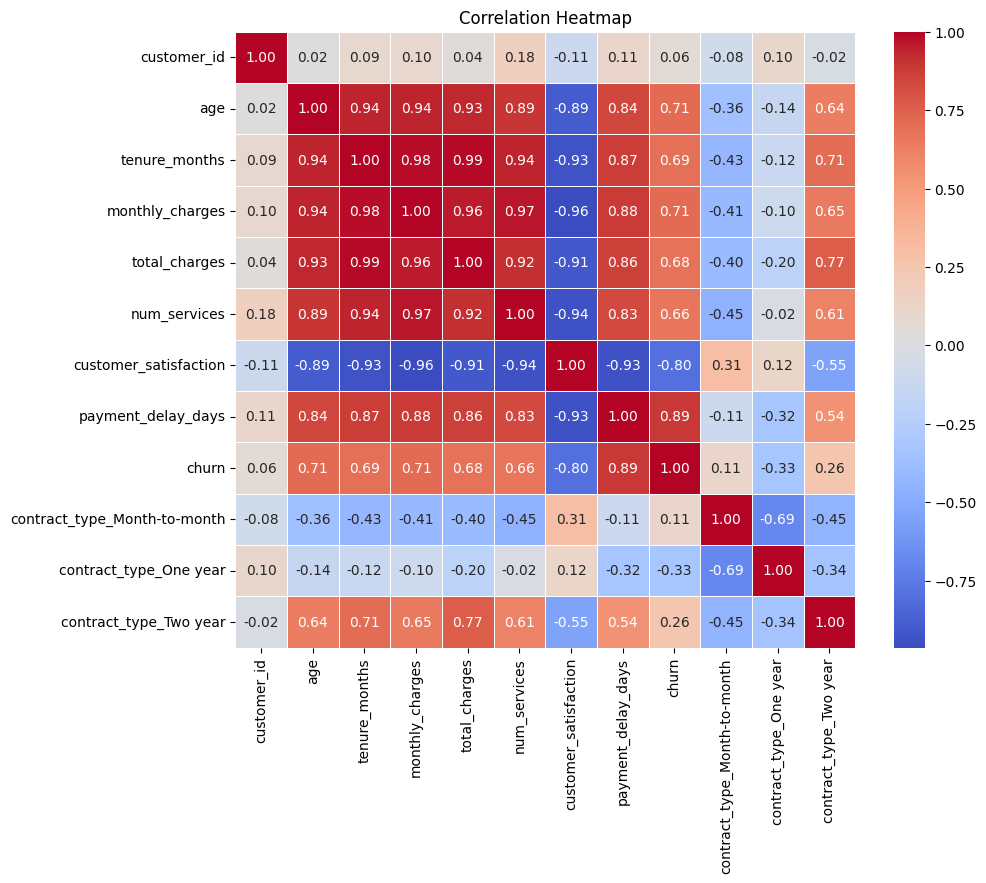

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df.drop(columns=['churn'])
y = df['churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
models = []
accuracy = []

models.append(('Logistic Regression', LogisticRegression()))
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('Decision Tree Entropy', DecisionTreeClassifier(criterion="entropy")))
models.append(('Random Forest', RandomForestClassifier()))

for name, model in models:
    model = model
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"Name of Model: {name} and the Accuracy score: {accuracy_score(y_test, predictions)}")
    accuracy.append((accuracy_score(y_test, predictions)))
    # print(classification_report(y_test, predictions))
    train = model.score(X_train, y_train)
    test = model.score(X_test, y_test)
    print(f"Train Score: {train} and Test Score: {test}")
    print("\n")
arr=np.array(accuracy)
print(arr.mean())

Name of Model: Logistic Regression and the Accuracy score: 0.9333333333333333
Train Score: 1.0 and Test Score: 0.9333333333333333


Name of Model: Decision Tree and the Accuracy score: 1.0
Train Score: 1.0 and Test Score: 1.0


Name of Model: Decision Tree Entropy and the Accuracy score: 1.0
Train Score: 1.0 and Test Score: 1.0


Name of Model: Random Forest and the Accuracy score: 0.9333333333333333
Train Score: 1.0 and Test Score: 0.9333333333333333


0.9666666666666668
